# Load network
Build edges, nodes, and adjacency list from the input file. 

In [3]:
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import random
import os
import matplotlib.pyplot as plt

edges = np.loadtxt("train.csv", delimiter=",", dtype=int).tolist()

g_full = nx.Graph()
g_full.add_edges_from(edges)

print(f"# of nodes: {g_full.number_of_nodes()}")
print(f"# of undirected edges: {g_full.number_of_edges()}")
print(f"degrees = min: {np.min(list(dict(g_full.degree()).values()))}, max: {np.max(list(dict(g_full.degree()).values()))}, p75: {np.percentile(list(dict(g_full.degree()).values()), 75):.2f}, median: {np.median(list(dict(g_full.degree()).values())):.2f}")

# of nodes: 2485
# of undirected edges: 4969
degrees = min: 1, max: 167, p75: 5.00, median: 3.00


## Setup visualizations

In [4]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

plot_counter = 1
def show_and_save_plot():
    global plot_counter
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    if not title:
        title = f"plot_{plot_counter:03d}"
        plot_counter += 1
    filename = "".join(c if c.isalnum() or c in "._-" else "_" for c in title).replace(" ", "_") + ".png"
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight', transparent=True)
    
plt.show = show_and_save_plot

In [5]:
def display_top_edges(new_edges_dict, name, k=10, save=True):
    """Display top-K edges based on a link prediction scoring measure and save them to a file."""
    top = sorted(new_edges_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    print(f"Top {k} edges by {name}:")
    for (node1, node2), score in top:
        print(f"Edge ({node1}, {node2}): {score:.4f}")

    nodes_, scores = zip(*top)
    plt.figure(figsize=(9, 4))
    plt.bar(range(len(top)), scores, color="tomato")
    plt.xticks(range(len(top)), nodes_)
    plt.grid(True, alpha=0.3, axis="y")
    plt.xlabel("Edge #")
    plt.ylabel("Score")
    plt.title(f"Top {k} edges by {name}")
    plt.tight_layout()
    plt.show()

    if save:
        with open("results.txt", "a") as f:
            f.write(" ".join(f"({node1}, {node2})" for (node1, node2), _ in top) + "\n")

# Plotting the graph

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

plots = [
    ("draw", lambda ax: nx.draw(g_full, ax=ax, node_size=20, width=0.5)),
    ("draw_networkx", lambda ax: nx.draw_networkx(g_full, ax=ax, node_size=20, width=0.5, with_labels=False)),
    ("spring", lambda ax: nx.draw_spring(g_full, ax=ax, node_size=20, width=0.5)),
    ("circular", lambda ax: nx.draw_circular(g_full, ax=ax, node_size=20, width=0.5)),
    ("shell", lambda ax: nx.draw_shell(g_full, ax=ax, node_size=20, width=0.5)),
    ("kamada_kawai", lambda ax: nx.draw_kamada_kawai(g_full, ax=ax, node_size=20, width=0.5)),
    ("spectral", lambda ax: nx.draw_spectral(g_full, ax=ax, node_size=20, width=0.5)),
    ("random", lambda ax: nx.draw_random(g_full, ax=ax, node_size=20, width=0.5)),
]

for ax, (title, plot_fn) in zip(axes, plots):
    plot_fn(ax)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Create benchmark set
"TRAIN" == SPLIT OF POSITIVE NODES, THE MODEL LOOKS AT THIS
"VAL" == SPLIT OF POSITIVE NODES + SAMPLED NEGATIVE NODES, THE MODEL SCORES THESE
y_true == ALL POSITIVE NODES IN VAL ARE 1, ALL NEGATIVE NODES IN VAL ARE 0
y_pred == THE TOP #POS_IN_VAL SCORING EDGES IN VAL ARE 1, THE REST ARE 0

In [6]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
NEGATIVE_RATIO = 9

# 80% train, 20% validation
X_train, X_val = train_test_split(edges, test_size=TEST_SIZE, random_state=42)
Y_train, Y_val = [1] * len(X_train), [1] * len(X_val)

# add negative edges
# X_train.extend(random.sample(list(nx.non_edges(g)), len(X_train)))
# Y_train.extend([0] * len(X_train))
X_val.extend(random.sample(list(nx.non_edges(g_full)), len(X_val) * NEGATIVE_RATIO))
Y_val.extend([0] * len(Y_val) * NEGATIVE_RATIO)

g_train = nx.Graph()
g_train.add_edges_from(X_train)

print(f"# of positive edges the model is trained on: {len(Y_train)}")
print(f"# of candidate nodes in validation set: {len(Y_val)} (positive: {Y_val.count(1)}, negative: {Y_val.count(0)}, ratio = {NEGATIVE_RATIO})")

# of positive edges the model is trained on: 3975
# of candidate nodes in validation set: 9940 (positive: 994, negative: 8946, ratio = 9)


# Link prediction
The idea is to create a **scoring function** $\sigma(x, y)$ that measures the **proximity** between two nodes. 

The **top-k** scoring pairs of nodes are the candidate for having a new edge, if they are not already connected.

There are several *families* of scoring methods:

## Neighborhood-based (degree)
1. **Common Neighbors**: the more common neighbors the more similar
$$
\sigma(x, y) = |N(x) \cap N(y)|
$$

2. **Jaccard Similarity**: ...but normalizes by the total number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{|N(x) \cup N(y)|}
$$

3. **Cosine Similarity**: ...but normalizes by the geometric mean of the number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{\sqrt{|N(x)| \cdot |N(y)|}}
$$

4. **Adamic and Adar**: gives more weight to common neighbors with fewer connections
$$
\sigma(x, y) = \sum_{z \in N(x) \cap N(y)} \frac{1}{\log |N(z)|}
$$

5. **Preferential Attachment**: the more _(common or not)_ neighbors the more similar
$$
\sigma(x, y) = |N(x)| \cdot |N(y)|
$$

> To avoid having zero similarity, add the node *itself* to its neighbors.

## Random Walk-based (distance)
1. **Katz 1953**: the more short paths exist between them, the more similar
$$
\sigma(x, y) = \sum_{l=1}^{\infty} \beta^l |\text{paths}_{x, y}^{(l)}| = \sum \beta^l (A^l)_{xy}
$$

2. **Personalized PageRank**: the more likely to reach each other in a random walk, the more similar
$$
\sigma(x, y) = r_x(y) + r_y(x)
$$

## Community-based (clusters)
1. **Spectral Clustering**: the closer the eigenvector embedding of the nodes in the graph Laplacian, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

2. **Modularity Maximization**: the closer the eigenvector embedding of the node in the graph Modularity, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

## Embedding-based
- TBD

## Method 1: Common Neighbors (neighborhood-based)

In [20]:
scores = np.zeros(len(X_val))
for i, candidate in enumerate(X_val):  # both positive and negative edges
    u, v = candidate
    if g_train.has_node(u) and g_train.has_node(v):
        scores[i] = len(list(nx.common_neighbors(g_train, u, v))) # in the graph with only positive edges

# Method 2: Spectral Clustering (community-based)

In [8]:
from scipy.sparse.linalg import eigsh

K = 10

L = nx.laplacian_matrix(g_train)
vals, vecs = eigsh(L, k=K+1, which="SM")  # smallest K+1 smallest eigenvalues and their eigenvectors
M = vecs[:, 1:]  # skipping trivial first eigenvector

# lookup required: M rows are ordered like g_train.nodes() so not in node ID order
node_to_row = {node: i for i, node in enumerate(g_train.nodes())}
embed_candidate = lambda candidate: (M[node_to_row[candidate[0]]], M[node_to_row[candidate[1]]])

In [9]:
from scipy.spatial.distance import cosine

scores = np.zeros(len(X_val))
for i, candidate in enumerate(X_val):  # both positive and negative edges
    if g_train.has_node(candidate[0]) and g_train.has_node(candidate[1]):
        u, v = embed_candidate(candidate)
        scores[i] = 1 - cosine(u, v)

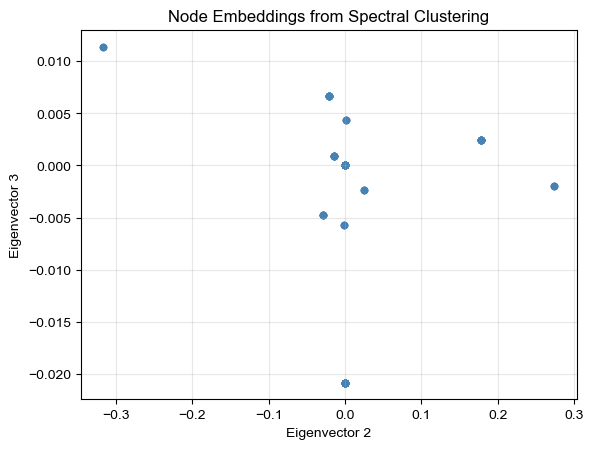

In [10]:
plt.figure()
plt.scatter(M[:, 0], M[:, 1], s=20, color="steelblue")
plt.title("Node Embeddings from Spectral Clustering")
plt.xlabel("Eigenvector 2")
plt.ylabel("Eigenvector 3")
plt.grid(True, alpha=0.3)
plt.show()

# Method 3: Cosine similarity (neighborhood-based)

In [29]:
scores = np.zeros(len(X_val))
for i, candidate in enumerate(X_val):  # both positive and negative edges
    u, v = candidate
    if g_train.has_node(u) and g_train.has_node(v):
        common_neighs = len(list(nx.common_neighbors(g_train, u, v)))
        norm = np.sqrt(g_train.degree(u) * g_train.degree(v))
        scores[i] = common_neighs / norm

# Evaluation

| | Predicted Positive | Predicted Negative |
|---|:-:|:-:|
| **Actual Positive** | TP | FN |
| **Actual Negative** | FP | TN |

* **TP**: edge exists and is predicted
* **FP**: edge *does not* exist but is predicted
* **FN**: edge exists but is *not* predicted
* **TN**: edge *does not* exist and is *not* predicted


$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} \quad\quad
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} \quad\quad
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

> The three metrics will match if the number of predicted positive edges matches the number of true positive edges in the validation set.

In [12]:
def binarize_scores(scores: np.ndarray, top_k=Y_val.count(1)) -> list[int]:
    """Map the scores to 1 if they belong to the top-k."""
    top_k_idx = np.argsort(scores)[-top_k:]
    pred = np.zeros(len(scores))
    pred[top_k_idx] = 1
    return pred.tolist()

In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score

Y_val_pred = binarize_scores(scores)
assert Y_val_pred.count(1) == Y_val.count(1), "The number of predicted positives must match the number of actual positives for a fair evaluation."

precision = precision_score(Y_val, Y_val_pred)
recall = recall_score(Y_val, Y_val_pred)
f1 = f1_score(Y_val, Y_val_pred)

print(f"PR: {precision:.4f}")
print(f"RE: {recall:.4f}")
print(f"F1: {f1:.4f}")

NameError: name 'binarize_scores' is not defined